# Rice phenology stage identification by multi-scale (20 m MR + 4 m HR) temporal fusion — inference demo

**Paper:** H. Wang, W. Guo, Y. Mu*, Y. Zhang, H. Wang, Y. Yang, H. Xu, Y. Ding, S. Zhou, G. Li, S. Ninomiya.
*Multi-scale spatial-temporal remote sensing fusion for phenology identification in rice germplasm resources.*
Plant Phenomics 8(3):100222, 2026. DOI [10.1016/j.plaphe.2026.100222](https://doi.org/10.1016/j.plaphe.2026.100222) · [PMC13207460](https://pmc.ncbi.nlm.nih.gov/articles/PMC13207460/)

**Author code (pinned):** [gfjiyue/Rice-phenology-identification-by-UAV](https://github.com/gfjiyue/Rice-phenology-identification-by-UAV) @ commit `5b9c2dd9e254ff7fd028c54047e2945a184ab9ce` (GPL-2.0).

## Scope / スコープ

**EN:** This notebook runs the authors' released batch-inference script (`predict.py`) **unchanged in its scientific logic** on the repository's own example data (`datatest/`: ten 2024 plots, five BBCH-based stage classes) with the released Δ=3 checkpoint. The model fuses a dense 20 m (MR) image stream with sparse 4 m (HR) images via Missing-Aware Gated Fusion (MAGF) and an LSTM, and predicts five stages per frame: Jointing, Heading/Flowering, Milky, Dough, Maturity. It produces per-frame/window CSV predictions, confusion matrices and OA/F1/Kappa on the example set. **This is an inference-only demonstration on 10 example plots — it does not reproduce training or the paper's dataset-level accuracy tables, and the authors do not document which paper table each released checkpoint corresponds to.**

**JP:** 論文の公開推論スクリプト `predict.py` を、リポジトリ同梱の例題データ `datatest/`（10 区画・5 段階）と公開済み Δ=3 チェックポイントでそのまま実行します。20 m MR を時系列アンカーとし、疎な 4 m HR を Missing-Aware Gated Fusion + LSTM で統合し、5 つの生育段階（JBS/HFS/MkS/DS/MS）を推定します。**推論のみのデモであり、学習や論文のデータセット精度表の再現ではありません。**

**Runtime:** Works on **CPU** and **T4 GPU** (auto-detected); T4 is faster but CPU is fully sufficient for this small example (≈130 MB of downloads, a few minutes end to end).

## Runtime selection / ランタイム選択

Prefer **Runtime → Change runtime type → T4 GPU** for speed; **CPU** also runs the whole demo. The code below auto-detects the device (the authors' own `torch.device` logic).

T4 GPU を推奨（高速）ですが、CPU でも動作します。デバイスは自動検出されます。

### Environment check
Verify the Python/PyTorch environment and the device. Colab's preinstalled torch/torchvision satisfy the authors' requirement (`torch==2.4.1`, `torchvision==0.19.1` recommended; any recent ≥2.x build works because the model uses only standard `torch.nn` layers).

環境とデバイスを確認します。Colab 標準の PyTorch で動作します。

In [ ]:
import sys, torch, torchvision, platform
print("Python", sys.version.split()[0], "| torch", torch.__version__, "| torchvision", torchvision.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (CPU)")

Python 3.13.15 | torch 2.11.0+cu130 | torchvision 0.26.0+cu130
Device: cuda | GPU: Tesla T4


## 1. Get the pinned author repository / 論文著者コードの取得

Fetch the **exact pinned commit** `5b9c2dd9e254ff7fd028c54047e2945a184ab9ce` with a partial clone (blob-filtered, sparse checkout) selecting only the code files, the example data (`datatest/`) and the Δ=3 checkpoint. The checkout is asserted against the pinned SHA. Everything stays under `/content` on the Colab VM.

固定コミットを部分クローンで取得します（必要なファイルのみ、SHA を検証）。

### Sparse-checkout the pinned commit
`--filter=blob:none --no-checkout` avoids downloading history blobs; the sparse set contains only what this demo needs. The clone stays in `/content` on Colab.

部分クローンでスパースチェックアウトし、コミット SHA を検証します。

In [ ]:
%%bash
set -e
rm -rf /content/repo
cd /content
git clone --filter=blob:none --no-checkout https://github.com/gfjiyue/Rice-phenology-identification-by-UAV.git repo
cd repo
git sparse-checkout init --cone
git sparse-checkout set datatest weight/checkpoints/delta3_mobilenetv3_mobilenetv3_T5_proj512
git fetch --depth 1 origin 5b9c2dd9e254ff7fd028c54047e2945a184ab9ce
git checkout --detach 5b9c2dd9e254ff7fd028c54047e2945a184ab9ce 2>/dev/null
echo "HEAD = $(git rev-parse HEAD)"
[ "$(git rev-parse HEAD)" = "5b9c2dd9e254ff7fd028c54047e2945a184ab9ce" ] && echo "PINNED COMMIT OK" || { echo "COMMIT MISMATCH"; exit 1; }
find datatest -name '*.tif' | wc -l
ls -lh weight/checkpoints/delta3_mobilenetv3_mobilenetv3_T5_proj512/

HEAD = 5b9c2dd9e254ff7fd028c54047e2945a184ab9ce
PINNED COMMIT OK
974
total 57M
-rw-r--r-- 1 root root 29M Oct  6 03:40 delta3_mobilenetv3_mobilenetv3_T5_proj512_best.pt
-rw-r--r-- 1 root root 29M Oct  6 03:40 delta3_mobilenetv3_mobilenetv3_T5_proj512_last.pt


Cloning into 'repo'...
From https://github.com/gfjiyue/Rice-phenology-identification-by-UAV
 * branch            5b9c2dd9e254ff7fd028c54047e2945a184ab9ce -> FETCH_HEAD


### Validate the downloaded bytes
Confirm the example-image count (974 TIFs across `20m/` and `4m/`), class folders, and that the checkpoint is a real torch file (not an HTML error page or LFS pointer).

ダウンロードしたファイル数・クラス構成・チェックポイントの実体を検証します。

In [ ]:
import os, glob, torch
REPO = "/content/repo"
t20 = glob.glob(f"{REPO}/datatest/20m/*/*.tif"); t4 = glob.glob(f"{REPO}/datatest/4m/*/*.tif")
print(f"20m TIFs: {len(t20)} | 4m TIFs: {len(t4)}")
ck = f"{REPO}/weight/checkpoints/delta3_mobilenetv3_mobilenetv3_T5_proj512/delta3_mobilenetv3_mobilenetv3_T5_proj512_best.pt"
size = os.path.getsize(ck)
sd = torch.load(ck, map_location="cpu", weights_only=True)
assert size > 10_000_000 and len(sd) > 50, "checkpoint failed sanity checks"
print(f"checkpoint: {os.path.basename(ck)} | {size/1e6:.1f} MB | {len(sd)} tensors | e.g. {list(sd.keys())[0]}")

20m TIFs: 540 | 4m TIFs: 434


checkpoint: delta3_mobilenetv3_mobilenetv3_T5_proj512_best.pt | 29.4 MB | 628 tensors | e.g. cnn20.0.0.0.weight


## 2. Input preview / 入力画像のプレビュー

Before running the model, look at the actual inputs: one 20 m (MR) plot image and one 4 m (HR) image of the same plot and date. The class folder is the ground-truth stage label used by the example data layout. (Filenames encode `PLOTID_YYYYMMDD_...`.)

モデル実行前に、同じ区画・同日の 20 m 画像と 4 m 画像を表示します（クラスフォルダ＝正解ラベル）。

### Display one MR/HR pair
Load the TIFs with PIL (the authors' loader also uses PIL) and show them side by side, labeled with plot, date and ground-truth class.

20 m / 4 m 画像ペアを PIL で読み込んで並べて表示します。

20m: /content/repo/datatest/20m/1_Jointing stage/J1B265_20240822_RGB20m.tif
4m:  /content/repo/datatest/4m/1_Jointing stage/J1B265_20240822_UAV4m.tif


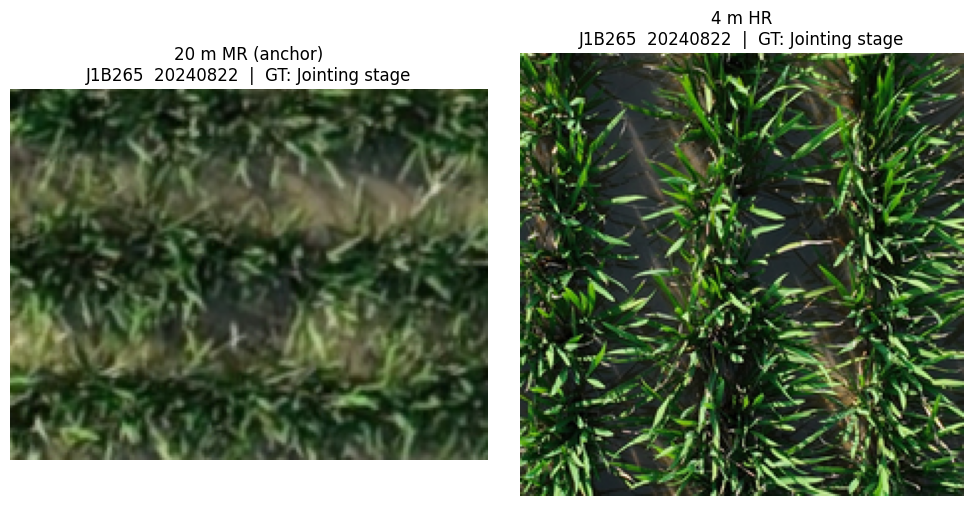

In [ ]:
import re, glob
from PIL import Image
import matplotlib.pyplot as plt

def pick(side, cls, plot):
    fs = sorted(glob.glob(f"{REPO}/datatest/{side}/{cls}/{plot}*.tif"))
    assert fs, f"no {side} image for {plot} in {cls}"
    return fs[0]

plot, date = "J1B265", "20240822"
p20 = pick("20m", "1_Jointing stage", plot)
p4  = pick("4m",  "1_Jointing stage", plot)
print("20m:", p20); print("4m: ", p4)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for a, p, tag in zip(ax, [p20, p4], ["20 m MR (anchor)", "4 m HR"]):
    a.imshow(Image.open(p).convert("RGB"))
    a.set_title(f"{tag}\n{plot}  {date}  |  GT: Jointing stage")
    a.axis("off")
plt.tight_layout(); plt.show()

### Dataset statistics
Count windows/frames per ground-truth class that the authors' dataset builder will produce for Δ=3. `predict.py` uses the exact same class-folder layout (5 classes; 20 m and 4 m folder names identical, so the intersection is used).

クラス別サンプル数を確認します（Δ=3 の HR ダウンサンプリング規則を含む）。

In [ ]:
import collections
c20 = collections.Counter(p.split("/")[-2] for p in t20)
c4  = collections.Counter(p.split("/")[-2] for p in t4)
for k in sorted(c20): print(f"{k:35s} 20m:{c20[k]:4d}  4m:{c4[k]:4d}")
print("Note: 4m images exist on 45 of the 59 20m dates; the rest are MR-only frames (mask4=0).")

1_Jointing stage                    20m:  70  4m:  69
2_Heading_Flowering stage           20m: 101  4m:  99
3_Milky stage                       20m:  75  4m:  75
4_Dough stage                       20m: 148  4m: 122
5_Maturity stage                    20m: 146  4m:  69
Note: 4m images exist on 45 of the 59 20m dates; the rest are MR-only frames (mask4=0).


## 3. Run the authors' inference script / 著者の推論スクリプトを実行

`predict.py` hardcodes dataset/output/weight paths, which the README says to edit before running. We patch **only** those path constants (and `DELTAS=[3]`) — no scientific logic is changed — then run the script. It builds `PhaseFolderSequenceDualDataset20mAnchor` windows (T=5), loads `delta3_..._best.pt`, runs MAGF+LSTM inference, and writes `frame_preds.csv`, `window_center_preds.csv`, two confusion-matrix PNGs, a metrics print, and `summary_predict.csv`.

`predict.py` のパス定数（と DELTAS）だけを README の指示どおりに書き換えて実行します。科学的手法は一切変更しません。

### Patch paths (README-instructed configuration) and run
`MAX_DATE_DIFF=0` means an HR image is used only when its date exactly matches the 20 m anchor date; other frames are MR-only with `mask4=0`, exercising the missing-aware fusion path.

パス定数のみ修正し、著者スクリプトをそのまま実行します。

In [ ]:
%%bash
set -e
cd /content/repo
python - <<'EOF'
import re
src = open("predict.py", encoding="utf-8").read()
src = src.replace('TEST_ROOT_20M = r"your dataset folder"#20m input path',
                  'TEST_ROOT_20M = r"/content/repo/datatest/20m"')
src = src.replace('TEST_ROOT_4M  = r"your dataset folder"#4m input path',
                  'TEST_ROOT_4M  = r"/content/repo/datatest/4m"')
src = src.replace('SAVE_ROOT     = r"Output root directory"   # Output root directory, automatically created',
                  'SAVE_ROOT     = r"/content/outputs"')
src = src.replace('weight=r"..\\1_code\\weight"# weight',
                  'weight=r"/content/repo/weight"')
src = src.replace("DELTAS         = [1]  # 1,2,3,4,5,6,7,10,14",
                  "DELTAS         = [3]  # 1,2,3,4,5,6,7,10,14")
open("predict_run.py", "w", encoding="utf-8").write(src)
import re as _re
assert '/content/repo/datatest/20m' in src and 'DELTAS         = [3]' in src
print("predict_run.py written; patched paths + DELTAS=[3]")
EOF
python predict_run.py

predict_run.py written; patched paths + DELTAS=[3]
Device: cuda

###  Start prediction  Δ = 3
[Δ=3] Windows=500 | Classes=['1_Jointing stage', '2_Heading_Flowering stage', '3_Milky stage', '4_Dough stage', '5_Maturity stage']
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
[Δ=3] OA=0.9460 P=0.9455 R=0.9297 F1=0.9359 Kappa=0.9304

All Delta predictions are complete. Summary:
/content/outputs/summary_predict.csv


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100%|██████████| 21.1M/21.1M [00:00<00:00, 159MB/s]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rati

## 4. Results / 結果

Inspect the script's outputs: the summary metrics table, the normalized confusion matrix it saved, and a few rows of per-frame predictions. Metrics here describe **this 10-plot example set only**, not the paper's test benchmarks.

出力された指標・混同行列・予測 CSV を確認します（この 5 区画の例題に対する結果であり、論文のベンチマークではありません）。

### Show summary metrics and per-frame predictions
Read the CSVs the author script wrote and display them.

著者スクリプトが出力した CSV を表示します。

In [ ]:
import pandas as pd
summary = pd.read_csv("/content/outputs/summary_predict.csv")
display(summary)
frame = pd.read_csv("/content/outputs/pred_outputs_delta3/frame_preds.csv")
print(f"\nframe predictions: {len(frame)} rows, plots: {sorted(frame['plot'].unique())}")
frame.head(8)

,delta,num_windows,OA,Precision,Recall,F1,Kappa
0,3,500,0.946,0.945517,0.929732,0.935948,0.930394



frame predictions: 2500 rows, plots: ['J1B206', 'J1B265', 'J1N350', 'J2B307', 'J2B439', 'J2B545', 'J2N269', 'J2N385', 'XB132', 'XN599']


,window,t,plot,date,phase_gt,pred,prob,has_4m
0,0,0,J1B265,2024-08-22,1_Jointing stage,1_Jointing stage,0.995459,1
1,0,1,J1B265,2024-08-23,1_Jointing stage,2_Heading_Flowering stage,0.786172,0
2,0,2,J1B265,2024-08-24,1_Jointing stage,2_Heading_Flowering stage,0.698701,0
3,0,3,J1B265,2024-08-25,1_Jointing stage,1_Jointing stage,0.996490,1
4,0,4,J1B265,2024-08-26,1_Jointing stage,2_Heading_Flowering stage,0.962390,0
5,1,0,J1B265,2024-08-23,1_Jointing stage,2_Heading_Flowering stage,0.902516,0
6,1,1,J1B265,2024-08-24,1_Jointing stage,2_Heading_Flowering stage,0.798214,0
7,1,2,J1B265,2024-08-25,1_Jointing stage,1_Jointing stage,0.995279,1


### Confusion matrix (saved by the author's script)
`predict.py` saved a raw and a normalized confusion matrix PNG from its own plotting function; show the normalized one.

著者スクリプトが保存した混同行列（正規化）を表示します。

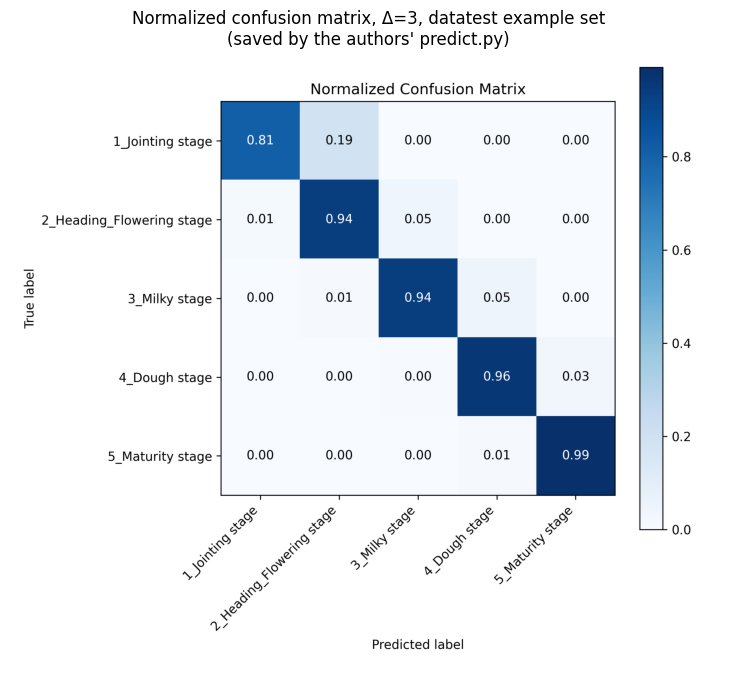

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("/content/outputs/pred_outputs_delta3/confusion_matrix_norm.png")
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(img); ax.axis("off")
ax.set_title("Normalized confusion matrix, Δ=3, datatest example set\n(saved by the authors' predict.py)")
plt.tight_layout(); plt.show()

### Per-plot prediction trajectory
An additional visualization created for this notebook (not an author figure): frame-level predicted vs. ground-truth stage for one plot over dates, showing how the MR-anchored sequence is classified through the season.

（このノートブック用に追加した可視化です）ある区画の日付ごとの予測段階と正解の推移を表示します。

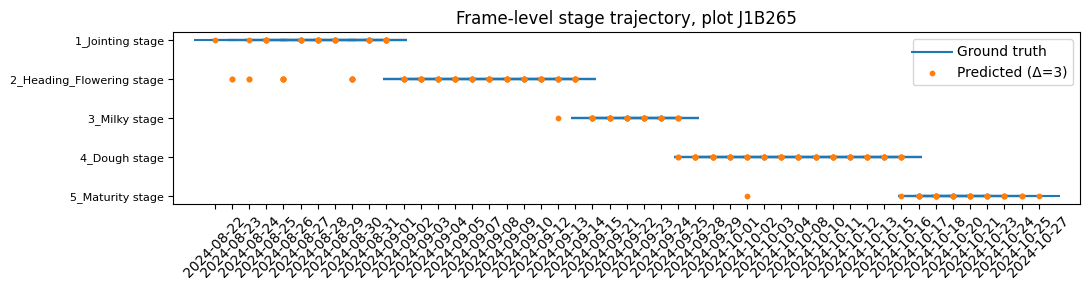

In [ ]:
import matplotlib.pyplot as plt
one = frame[frame["plot"] == frame["plot"].iloc[0]].sort_values("date")
fig, ax = plt.subplots(figsize=(11, 3))
classes = sorted(frame["phase_gt"].unique())
cmap = {c: i for i, c in enumerate(classes)}
ax.scatter(one["date"], [cmap[v] for v in one["phase_gt"]], marker="_", s=900, label="Ground truth")
ax.scatter(one["date"], [cmap[v] for v in one["pred"]], marker=".", s=40, label="Predicted (Δ=3)")
ax.set_yticks(range(len(classes)), classes, fontsize=8)
ax.invert_yaxis(); ax.legend(); ax.set_title(f"Frame-level stage trajectory, plot {one['plot'].iloc[0]}")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 5. Interpretation and limitations / 解釈と限界

**EN:** On this 10-plot example set the released Δ=3 checkpoint predicts the five stages frame-by-frame; the confusion matrix and OA/F1/Kappa printed above summarize its agreement with the example-folder labels. This demonstrates that the released code + weights + example data run end-to-end (the MAGF + LSTM inference path, including MR-only frames with `mask4=0`). It does **not** validate the paper's dataset-level results (Table 3: async MR+HR+LSTM OA/F1 0.873, Kappa 0.840; cross-year Δ=3 OA 0.774), because the >100,000-image training/test data is not public and the authors do not map each released checkpoint to a paper table. Training and the field-scale mapping experiments (Fig. 7) are out of scope.

**JP:** 公開コード＋重み＋例題データで MAGF+LSTM 推論パス（HR 欠損フレームを含む）が一通り動作することを確認しました。ただし 10 万枚規模のデータは非公開のため、論文のデータセット精度（Table 3 等）の検証にはなりません。学習と田圃スケールのマッピング実験は対象外です。

**Sources:** author code @ `5b9c2dd9e254ff7fd028c54047e2945a184ab9ce` (`predict.py`, `dataset.py`, `model_mv3.py`); paper PMC13207460 (Sections 2.3, 3.4, 3.5); PhenoPaper investigation `p-a349992a9a7f836d25123f526c58c28a-20260930T154955Z-3770296` used as prior research guidance only.